

Este notebook trabaja con un problema de regresion lineal multiple: queremos predecir una variable continua a partir de varias caracteristicas.

La regresion lineal intenta encontrar una relacion del tipo:

$$ h_{\theta}(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n $$

donde:
- $x_1, x_2, ..., x_n$ son las variables de entrada
- $\theta_0, \theta_1, ..., \theta_n$ son los parametros que el modelo debe aprender

La meta es ajustar esos parametros para que la prediccion se acerque lo mis posible a los valores reales.

In [30]:
import numpy as np
from matplotlib import pyplot as plt

## Dataset: BlogFeedback

**Fuente:** UCI Machine Learning Repository  
**Enlace:** https://archive.ics.uci.edu/dataset/304/blogfeedback

### Descripción
El dataset **BlogFeedback** contiene características extraídas de publicaciones de blogs.  
El objetivo es predecir la **cantidad de comentarios** que recibirá una publicación

In [31]:

data = np.loadtxt('blogData_train.csv', delimiter=',')

X, y = data[:,:-1 ], data[:,-1]

In [ ]:
print(X)
print(y)

[[40.30467  53.845657  0.       ...  0.        0.        0.      ]
 [40.30467  53.845657  0.       ...  0.        0.        0.      ]
 [40.30467  53.845657  0.       ...  0.        0.        0.      ]
 ...
 [ 0.        0.        0.       ...  0.        0.        0.      ]
 [ 0.        0.        0.       ...  0.        0.        0.      ]
 [ 0.        0.        0.       ...  0.        0.        0.      ]]
[1. 0. 0. ... 0. 0. 0.]


In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
m=y_train.size
print(X_train.shape)
print(X_test.shape)

(41917, 280)
(10480, 280)


### ¿Por que normalizar las caracteristicas?

En muchos datasets, las columnas tienen escalas muy distintas. Por ejemplo, una caracteristica puede estar en valores grandes y otra en valores pequeños.

Para evitar que una variable domine a las dem?s, se normaliza cada columna con la media y la desviacion estandar:

$$ x_{norm} = \frac{x - \mu}{\sigma} $$

donde:
- $\mu$ es la media
- $\sigma$ es la desviaci?n estandar

Esto hace que los datos queden con una escala comparable y ayuda a que el algoritmo converja mejor.

In [34]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


In [35]:
X_norm, mu, sigma = featureNormalize(X_train)
X_test_norm = (X_test - mu) / sigma
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)
X_norm.shape

Media calculada: [ 3.95500600e+01  4.69101521e+01  3.69587518e-01  3.40474342e+02
  2.47472386e+01  1.52592578e+01  2.80155443e+01  2.91051363e-03
  2.59101152e+02  5.86974259e+00  1.40912019e+01  2.81703175e+01
  0.00000000e+00  2.57281890e+02  3.66350168e+00  3.49837436e+01
  4.16940926e+01  3.69587518e-01  2.86671875e+02  2.19885846e+01
  1.16805589e+00  3.94530429e+01 -2.27235728e+02  2.52848701e+02
 -4.66147387e-01  5.04002615e-01  7.81116698e-01  2.33795357e-03
  5.55841305e+00  2.80781067e-01  1.92614109e-01  4.87671197e-01
  0.00000000e+00  4.40479996e+00  1.94312570e-02  1.80828123e-01
  4.82679199e-01  0.00000000e+00  4.39005654e+00  4.41348379e-04
  4.59686242e-01  7.28590154e-01  2.33795357e-03  5.05494191e+00
  1.72400219e-01  1.17859853e-02  6.88031684e-01 -3.93980962e+00
  4.30004533e+00  3.33993368e-04  3.92535248e+01  1.52031873e+01
  1.39591335e+01  3.47197319e+01  1.24405373e+00  5.04902546e-01
  1.93835437e-01  1.80833552e-01  4.60362144e-01  1.30018847e-02
  3.4758

(41917, 280)

In [36]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
X.shape

(41917, 281)

### Funcion de costo y descenso por gradiente

El error del modelo se mide con una funcion de costo. En regresion lineal, normalmente se usa el error cuadritico medio:

$$ J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})^2 $$

Aqu?:
- $m$ es el numero de ejemplos
- $h_{\theta}(x)$ es la prediccion
- $y$ es el valor real

El descenso por gradiente ajusta los paremetros reduciendo el costo paso a paso:

$$ \theta := \theta - \alpha \frac{1}{m} X^T (X\theta - y) $$

donde $\alpha$ es la tasa de aprendizaje. Si la tasa es adecuada, el costo baja hasta llegar a un minimo.

In [37]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [38]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
       # Calcular el error (predicción - real)
        error = np.dot(X, theta) - y

        # Multiplicar por X transpuesta (X.T)
        gradiente = (1 / m) * np.dot(X.T, error)

        # Actualizar theta
        theta = theta - alpha * gradiente

        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

theta calculado por el descenso por el gradiente: [ 6.79046688e+00 -1.47833875e+00  4.10768235e+00 -2.59221956e-01
  6.93788440e-01  2.02449037e+00  5.19116510e+00  8.65505081e-01
 -7.33159065e-02 -1.09767091e-01  5.81903342e+00  5.09123645e+00
  3.96460608e-01  0.00000000e+00 -1.23159268e+00  7.61536913e-01
 -4.27586156e+00 -1.64530339e+00 -2.59221956e-01 -7.99116801e-01
  1.12263020e+00  5.40556820e+00 -3.44493676e+00 -3.79242948e+00
 -2.73390570e+00  6.65801317e-01 -4.37722981e+00  1.03893907e+00
  1.82924947e-01  1.40254855e-01  1.02272357e+00  3.79155900e+00
 -1.22245593e+00  0.00000000e+00  5.95985185e-01 -1.37845552e-01
  4.00308003e+00 -1.64272643e+00  0.00000000e+00  8.41678447e-01
  4.96962995e-03 -3.26559480e+00  4.30813171e+00  1.82924947e-01
  8.66244078e-02 -6.82430309e-01 -2.45870846e-01 -2.27740436e+00
  1.76348920e+00 -4.01255642e-01 -8.28351905e-02 -5.43808760e+00
  8.17172450e+00  1.72936170e+00 -1.93341260e+00  5.39566798e+00
 -1.08039746e+00  3.34008258e-01  2.6567

Text(0, 0.5, 'Costo J')

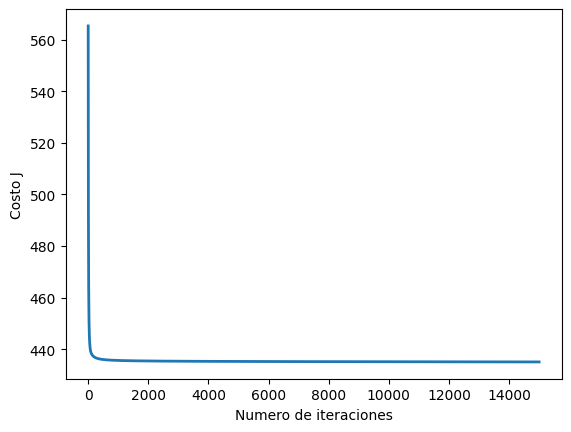

In [39]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.03 # alpha = 0.003
num_iters = 15000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y_train, theta, alpha, num_iters)
# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))
print(f"con un costo de: { J_history[-2]} ")
# Grafica la convergencia del costo
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')

### Resultados del Descenso por Gradiente

Después de entrenar el modelo con descenso por gradiente se obtuvo:

- **Vector θ:** 281 parámetros (280 features + bias)
- **Costo final:** 435.09

El costo indica el error residual del modelo. Un valor de aproximadamente 435 sugiere que el modelo captura parte de la relación entre las características y el número de comentarios, aunque aún existe un error considerable debido a la naturaleza ruidosa del dataset y a la alta dimensionalidad (280 features).

Algunos coeficientes cercanos a cero indican que ciertas variables tienen poca influencia en la predicción.

In [40]:
predicciones = []
for i in range(len(X_test_norm)):
    muestra_escalada = X_test_norm[i]
    xp = np.concatenate([[1], muestra_escalada])
    temp_pred = np.dot(xp, theta)
    predicciones.append(temp_pred)
    print(f"Muestra {i+1:3d}: Predicha={temp_pred:6.2f} | Real={y_test[i]:6.2f}")

Muestra   1: Predicha= 12.56 | Real=  0.00
Muestra   2: Predicha= 54.25 | Real= 51.00
Muestra   3: Predicha=  6.95 | Real=  0.00
Muestra   4: Predicha=  7.20 | Real=  2.00
Muestra   5: Predicha= -0.64 | Real=  0.00
Muestra   6: Predicha=  2.02 | Real=  0.00
Muestra   7: Predicha=  2.36 | Real=  0.00
Muestra   8: Predicha=  0.83 | Real=  0.00
Muestra   9: Predicha=  4.47 | Real=  0.00
Muestra  10: Predicha=  6.20 | Real=  0.00
Muestra  11: Predicha=  3.57 | Real=  0.00
Muestra  12: Predicha=  2.50 | Real=  0.00
Muestra  13: Predicha= -3.52 | Real=  1.00
Muestra  14: Predicha= -3.86 | Real=  0.00
Muestra  15: Predicha=  2.20 | Real=  3.00
Muestra  16: Predicha= 15.68 | Real= 13.00
Muestra  17: Predicha= -5.92 | Real=  0.00
Muestra  18: Predicha=  4.91 | Real=  2.00
Muestra  19: Predicha= 30.54 | Real=  2.00
Muestra  20: Predicha=  2.77 | Real=  0.00
Muestra  21: Predicha= -6.35 | Real=  0.00
Muestra  22: Predicha=  7.83 | Real=  0.00
Muestra  23: Predicha=  8.93 | Real=  4.00
Muestra  24

In [41]:
predicciones = np.array(predicciones)
reales = y_test

mae = np.mean(np.abs(predicciones - reales))
rmse = np.sqrt(np.mean((predicciones - reales)**2))
r2 = 1 - np.sum((predicciones - reales)**2) / np.sum((reales - np.mean(reales))**2)

print(f"MAE:  {mae:.2f} {'Bueno' if mae < 30 else 'Regular' if mae < 50 else 'Malo'}")
print(f"RMSE: {rmse:.2f} {'Bueno' if rmse < 40 else 'Regular' if rmse < 60 else 'Malo'}")
print(f"R2:   {r2:.4f}  {'Bueno' if r2 >= 0.75 else 'Regular' if r2 >= 0.50 else 'Malo'}")

MAE:  9.69 Bueno
RMSE: 32.42 Bueno
R2:   0.2939  Malo


Despues de entrenar el modelo, se evalua con metricas como:
- MAE: error absoluto medio
- RMSE: raiz del error cuaditico medio
- $R^2$: que tan bien explica el modelo la variabilidad de los datos

Estas metricas ayudan a comparar si el modelo esta realizando predicciones buenas, regulares o malas.
como  nuestros resultadoa que son  MAE RMSE SON BUenos pero R2 es malo 


### Ecuacion normal y evaluacion del modelo

Ademas del descenso por gradiente, existe otra forma de obtener los parametros:

$$ \theta = (X^T X)^{-1} X^T y $$

Esto se conoce como ecuacian normal. En algunos casos da una solucion directa sin iteraciones.



In [58]:

data = np.loadtxt('blogData_train.csv', delimiter=',')

X, y = data[:,:-1 ], data[:,-1]

In [67]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T,X)),X.T),y)

    return theta

In [60]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
m=y_train.size
print(X_train.shape)
print(X_test.shape)

(41917, 280)
(10480, 280)


In [ ]:
X = np.concatenate([np.ones((m, 1)), X_train], axis=1)
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y_train);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));


Theta calculado a partir de la ecuación de la normal: [ 3.63376428e+00 -1.93223608e-01  2.72009794e-01  7.26554986e-02
 -5.66685769e-03 -5.45595689e-02  9.17763090e-01 -1.76737510e-01
 -1.36472350e+00  1.53474041e-03  4.87493431e-01  6.47157064e-01
 -6.31773720e-01 -1.04289551e-04  2.85059298e-03 -5.85725934e-01
 -3.21700073e-01 -4.83901426e-03  7.30919451e-02  3.71890087e-03
  1.40551219e-01  2.70351722e-01  2.38319530e-01 -9.19612235e-03
 -7.80993977e-03  1.05954314e-01 -1.08623308e+01 -1.87620806e+00
  3.17862698e+00  4.10839781e-01  1.06980591e+00  1.02468825e+01
  5.12179311e+00  1.91896911e-11 -1.19899275e+00 -3.30572940e+00
  2.54268572e+01 -2.47469593e+01  1.94213207e-10  1.89163756e+00
 -9.01707717e+00 -2.26248152e+00  1.02091263e+01  3.17859568e+00
 -5.10463377e-01 -8.23777553e-01 -1.51799821e+01  5.89685657e+00
  4.44129315e-01 -3.46996065e-01 -4.07473756e+00 -4.96368532e-02
  1.30548802e-01  4.15835094e-02 -1.98547134e-02  8.89663332e-02
 -6.27321723e-01  3.55800540e-01  2.

In [ ]:
for i in range(len(X_test)):
    muestra_escalada = X_test[i]
    xp = np.concatenate([[1], muestra_escalada])
    temp_pred = np.dot(xp, theta)
    print(f"Muestra {i+1:3d}: Predicha={temp_pred:6.2f} | Real={y_test[i]:6.2f}")

Muestra   1: Predicha= 10.76 | Real=  0.00
Muestra   2: Predicha= 53.98 | Real= 51.00
Muestra   3: Predicha=  8.52 | Real=  0.00
Muestra   4: Predicha=  7.10 | Real=  2.00
Muestra   5: Predicha= -1.29 | Real=  0.00
Muestra   6: Predicha=  2.09 | Real=  0.00
Muestra   7: Predicha=  2.22 | Real=  0.00
Muestra   8: Predicha=  0.74 | Real=  0.00
Muestra   9: Predicha=  4.86 | Real=  0.00
Muestra  10: Predicha=  6.09 | Real=  0.00
Muestra  11: Predicha=  2.42 | Real=  0.00
Muestra  12: Predicha=  2.51 | Real=  0.00
Muestra  13: Predicha= -3.76 | Real=  1.00
Muestra  14: Predicha= -3.90 | Real=  0.00
Muestra  15: Predicha=  1.95 | Real=  3.00
Muestra  16: Predicha= 16.27 | Real= 13.00
Muestra  17: Predicha= -6.10 | Real=  0.00
Muestra  18: Predicha=  4.88 | Real=  2.00
Muestra  19: Predicha= 30.69 | Real=  2.00
Muestra  20: Predicha=  2.66 | Real=  0.00
Muestra  21: Predicha= -5.62 | Real=  0.00
Muestra  22: Predicha=  7.98 | Real=  0.00
Muestra  23: Predicha=  9.09 | Real=  4.00
Muestra  24